# House Price Prediction using Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression

# 2. Dataset Overview
The dataset is successfully loaded and parsed:

* Total Observations (Rows): 4200 

* Dependent Variable (Target): house_price_inr

* Independent Variables (Features): 4 features, including continuous variables (area_sqft, bedroom, bathroom, location_score).

In [2]:
df = pd.read_csv("after_houseprice_dataset.csv")
df.head()

,area_sqft,bedrooms,bathrooms,location_score,house_price_inr
0,1973,5,4,7.6,40275084
1,1560,3,3,6.3,26812029
2,2071,4,3,5.8,29315677
3,2640,5,3,7.7,47712959
4,1498,3,3,3.8,17724566


In [3]:
df.shape

(4200, 5)

In [4]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

##  Dataset & Preprocessing
* **Dataset:** The data is loaded from the `after_houseprice_dataset.csv` file into a pandas DataFrame, containing a total of 4,200 observations.
* **Features (X):** The features extracted to train the model are `area_sqft`, `bedrooms`, and `bathrooms` (selected via `df.iloc[:,0:3]`). 
* **Target Variable (y):** The final column of the dataset, `house_price_inr`, is set as the dependent (target) variable.
* **Data Splitting:** The dataset is split into training and testing sets using the `train_test_split` function. 70% of the data is allocated for training, while 30% (1,260 rows) is reserved for testing, using a `random_state=1` for reproducibility.

In [6]:


model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##  Model Implementation
* The `LinearRegression` algorithm from the `sklearn.linear_model` module is initialized.
* The model is then fitted (trained) on the `X_train` and `y_train` sets so it can learn the linear relationship between the selected features and the house prices.

In [7]:
# Residual
y_pred = model.predict(X_test)

residual = y_test - y_pred

In [8]:
y_pred

array([23411330.28614515, 10530304.05542482, 13130221.41904887, ...,
       20271195.15547157, 25394845.73570128, 39250969.96554119],
      shape=(1260,))

In [9]:
y_test

array([22567061, 15197046, 27093948, ..., 22137162, 36058604, 25509755],
      shape=(1260,))

In [10]:
residual

array([  -844269.28614515,   4666741.94457518,  13963726.58095113, ...,
         1865966.84452843,  10663758.26429872, -13741214.96554119],
      shape=(1260,))

In [11]:
lr = LinearRegression()

In [12]:
X_test

array([[1650,    4,    3],
       [ 782,    2,    2],
       [ 990,    4,    2],
       ...,
       [1422,    4,    4],
       [1761,    4,    4],
       [2716,    5,    3]], shape=(1260, 3))

In [13]:
y_test

array([22567061, 15197046, 27093948, ..., 22137162, 36058604, 25509755],
      shape=(1260,))

##  Prediction & Residuals
* Once the training is complete, the model generates predicted house prices (`y_pred`) using the `X_test` data.
* To evaluate the model's performance, the residuals are calculated. These represent the difference between the actual test prices (`y_test`) and the model's predictions (`y_pred`), calculated as `y_test - y_pred`.

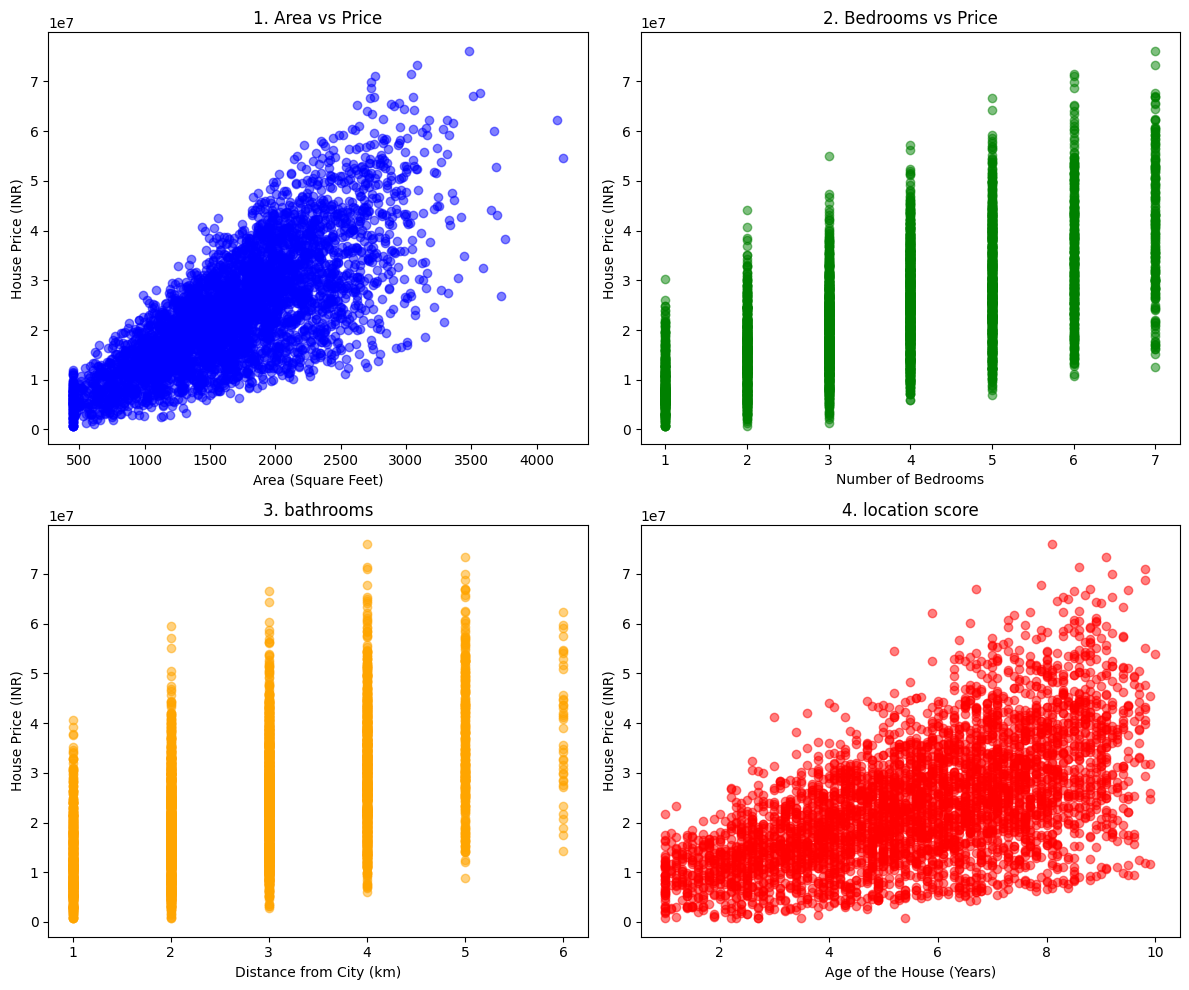

In [14]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# --- Plot 1: Area vs Price (Row 0, Col 0) ---
axes[0, 0].scatter(df['area_sqft'], df['house_price_inr'], color='blue', alpha=0.5)
axes[0, 0].set_title('1. Area vs Price')
axes[0, 0].set_xlabel('Area (Square Feet)')
axes[0, 0].set_ylabel('House Price (INR)')

# --- Plot 2: Bedrooms vs Price (Row 0, Col 1) ---
axes[0, 1].scatter(df['bedrooms'], df['house_price_inr'], color='green', alpha=0.5)
axes[0, 1].set_title('2. Bedrooms vs Price')
axes[0, 1].set_xlabel('Number of Bedrooms')
axes[0, 1].set_ylabel('House Price (INR)')

# --- Plot 3: Distance to City vs Price (Row 1, Col 0) ---
axes[1, 0].scatter(df["bathrooms"], df['house_price_inr'], color='orange', alpha=0.5)
axes[1, 0].set_title('3. bathrooms')
axes[1, 0].set_xlabel('Distance from City (km)')
axes[1, 0].set_ylabel('House Price (INR)')

# --- Plot 4: Age vs Price (Row 1, Col 1) ---
axes[1, 1].scatter(df["location_score"], df['house_price_inr'], color='red', alpha=0.5)
axes[1, 1].set_title('4. location score')
axes[1, 1].set_xlabel('Age of the House (Years)')
axes[1, 1].set_ylabel('House Price (INR)')

# tight_layout() ensure karta hai ki graph ke labels ek dusre par overlap na karein
plt.tight_layout()

# Graph show karein
plt.show()

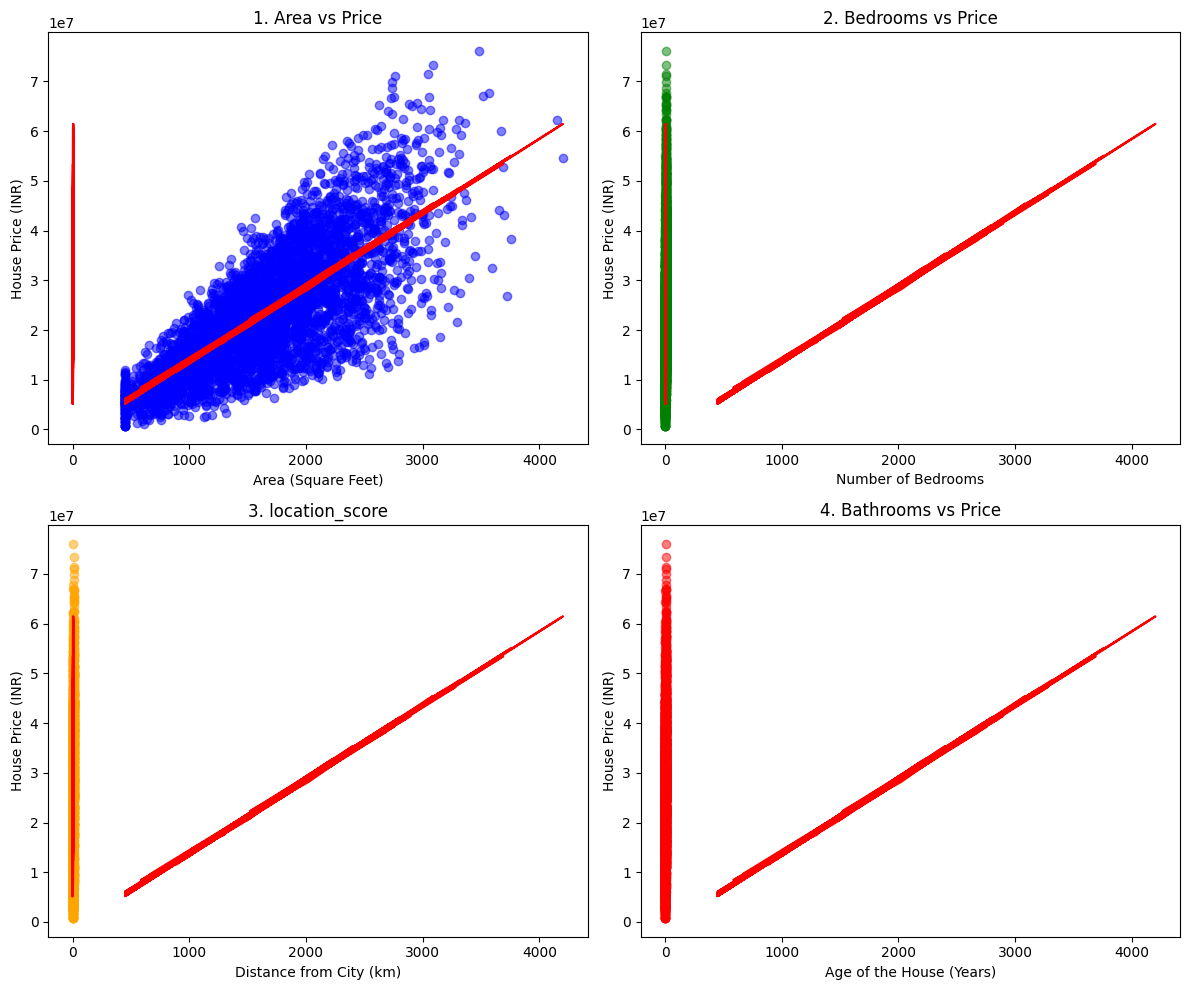

In [15]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# --- Plot 1: Area vs Price (Row 0, Col 0) ---
axes[0, 0].scatter(df['area_sqft'], df['house_price_inr'], color='blue', alpha=0.5)
axes[0, 0].plot(X_train,model.predict(X_train),color="red")
axes[0, 0].set_title('1. Area vs Price')
axes[0, 0].set_xlabel('Area (Square Feet)')
axes[0, 0].set_ylabel('House Price (INR)')

# --- Plot 2: Bedrooms vs Price (Row 0, Col 1) ---
axes[0, 1].scatter(df['bedrooms'], df['house_price_inr'], color='green', alpha=0.5)
axes[0, 1].plot(X_train,model.predict(X_train),color="red")
axes[0, 1].set_title('2. Bedrooms vs Price')
axes[0, 1].set_xlabel('Number of Bedrooms')
axes[0, 1].set_ylabel('House Price (INR)')

# --- Plot 3: Distance to City vs Price (Row 1, Col 0) ---
axes[1, 0].scatter(df["location_score"], df['house_price_inr'], color='orange', alpha=0.5)
axes[1, 0].plot(X_train,model.predict(X_train),color="red")
axes[1, 0].set_title('3. location_score')
axes[1, 0].set_xlabel('Distance from City (km)')
axes[1, 0].set_ylabel('House Price (INR)')

# --- Plot 4: Age vs Price (Row 1, Col 1) ---
axes[1, 1].scatter(df["bathrooms"], df['house_price_inr'], color='red', alpha=0.5)
axes[1, 1].plot(X_train,model.predict(X_train),color="red")
axes[1, 1].set_title('4. Bathrooms vs Price')
axes[1, 1].set_xlabel('Age of the House (Years)')
axes[1, 1].set_ylabel('House Price (INR)')

# tight_layout() ensure karta hai ki graph ke labels ek dusre par overlap na karein
plt.tight_layout()

# Graph show karein
plt.show()

In [16]:
m = model.coef_

In [17]:
m

array([  15114.013511  , -271898.72333219,  305859.94983489])

In [18]:
b = model.intercept_

In [19]:
b

np.float64(-1356776.9631842151)

In [20]:
# y = mx + b

m * 8.58 + b

array([-1227098.72725982, -3689668.00937444,  1267501.40639918])

In [21]:
# Step 1: Identify Dependent (Target) and Independent (Feature) Variables
print("=" * 70)
print("VARIABLE IDENTIFICATION")
print("=" * 70)

# Target variable (Dependent Variable)
target_variable = 'house_price_inr'
print(f"\n Dependent Variable (Target): {target_variable}")

# Independent variables (Features)
feature_variables = [col for col in df.columns if col != target_variable]
print(f"\n Independent Variables (Features): {len(feature_variables)}")
for i, feature in enumerate(feature_variables, 1):
    print(f"   {i}. {feature}")

# Separate X (features) and y (target)
X = df[feature_variables]
y = df[target_variable]

print(f"\n✓ Features shape (X): {X.shape}")
print(f"✓ Target shape (y): {y.shape}")

VARIABLE IDENTIFICATION

 Dependent Variable (Target): house_price_inr

 Independent Variables (Features): 4
   1. area_sqft
   2. bedrooms
   3. bathrooms
   4. location_score

✓ Features shape (X): (4200, 4)
✓ Target shape (y): (4200,)
